In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

tickers = ['PLY.AX', 'LAU.AX', 'COS.AX', 'ANG.AX', 'VVA.AX',
           'WTC.AX', 'AUB.AX', 'TLX.AX', 'DUG.AX']

data = yf.download(tickers, period='5y', interval='1d')['Close']

daily_log_returns = np.log(data / data.shift(1))

monthly_prices = data.resample('ME').last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1))[1:]

monthly_volatility = daily_log_returns.resample('ME').std()[1:]

result = pd.concat({
    'monthly_return': monthly_returns,
    'monthly_vol': monthly_volatility
}, axis=1).dropna()

print(monthly_returns.shape, monthly_volatility.shape)

[*********************100%***********************]  9 of 9 completed

(60, 9) (60, 9)


In [11]:
momentum = monthly_returns.rolling(window=3).sum().shift(1)
momentum = momentum.dropna()

volume_data = yf.download(tickers, period='5y', interval='1d')['Volume']
liquidity = np.log(volume_data.resample('ME').sum())

market_data = yf.download('^AXJO', period='5y', interval='1d')['Close']
market_data = market_data.resample('ME').last()
market_ret = np.log(market_data/market_data.shift(1)).dropna()

market_ret_df = pd.DataFrame(
    np.tile(market_ret.values.reshape(-1, 1), (1, len(tickers))),
    index=market_ret.index,
    columns=tickers
)

df = pd.concat({
    'return': monthly_returns,
    'vol': monthly_volatility,
    'momentum': momentum,
    'liquidity': liquidity,
    'market performance': market_ret_df
}, axis=1).dropna()


[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
print(market_ret_df.columns)

Index(['PLY.AX', 'LAU.AX', 'COS.AX', 'ANG.AX', 'VVA.AX', 'WTC.AX', 'AUB.AX',
       'TLX.AX', 'DUG.AX'],
      dtype='object')


In [13]:
betas = pd.DataFrame()
r_sq = {}

for stock in tickers:
    
    y = df['return'][stock]
    
    X = pd.concat([
        df['vol'][stock],
        df['momentum'][stock],
        df['liquidity'][stock],
        df[('market performance', stock)]], axis=1)
    
    X.columns = ['vol', 'momentum', 'liquidity', 'market performance']
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={'maxlags':5})
    
    betas[stock] = model.params
    r_sq[stock] = model.rsquared

betas = betas.T
r_sq = pd.Series(r_sq)

print(betas)
print(f"\n{r_sq}")

           const       vol  momentum  liquidity  market performance
PLY.AX  0.066057 -2.300878  0.125463   0.002334            1.578578
LAU.AX -0.034765  3.629638 -0.028282  -0.002798            0.794489
COS.AX  0.287355 -3.326080 -0.051313  -0.015183            0.487560
ANG.AX  0.427202 -1.598565 -0.014966  -0.022492            0.907329
VVA.AX -0.449234  3.013805 -0.066931   0.025923            0.645460
WTC.AX  0.593547 -2.116521 -0.016294  -0.033069            1.761561
AUB.AX  0.314221 -3.651497 -0.150194  -0.016018            0.704605
TLX.AX  1.033108 -1.167976 -0.072618  -0.057380            0.950204
DUG.AX  0.061136  6.076260  0.214612  -0.016742            0.426436

PLY.AX    0.181508
LAU.AX    0.138968
COS.AX    0.316911
ANG.AX    0.161185
VVA.AX    0.166033
WTC.AX    0.358433
AUB.AX    0.291912
TLX.AX    0.096754
DUG.AX    0.219915
dtype: float64


In [14]:
factor_returns = {}

for month in df.index:
    y = df.loc[month, 'return']   
    
    X = pd.concat([
        df.loc[month, 'vol'],
        df.loc[month, 'momentum'],
        df.loc[month, 'liquidity']
    ], axis=1)
    
    X.columns = ['vol', 'momentum', 'liquidity']
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    factor_returns[month] = model.params

factor_returns = pd.DataFrame(factor_returns).T

print(factor_returns)

               const        vol  momentum  liquidity
2021-09-30 -0.174377   8.282421 -0.053515  -0.000926
2021-10-31 -0.689898  16.014403 -0.118223   0.019539
2021-11-30  0.610558  -1.024017  0.256528  -0.040651
2021-12-31 -0.552642   1.369749  0.113397   0.037177
2022-01-31  0.022354   3.712712 -0.139821  -0.014757
2022-02-28  0.572043   2.373132 -0.115985  -0.044717
2022-03-31 -0.096304  -5.663850  0.156376   0.018998
2022-04-30  0.317203   1.603205 -0.137872  -0.026443
2022-05-31  0.078030  -6.750563 -0.665810   0.001749
2022-06-30 -0.180639   3.027071  1.310024   0.005556
2022-07-31 -0.711124   3.414003  0.110873   0.051914
2022-08-31 -1.202433  -0.361820 -0.598671   0.083339
2022-09-30  0.553338  -1.914013  0.276168  -0.042407
2022-10-31 -1.654116   4.657558 -0.001444   0.101825
2022-11-30  0.314424  -1.179620 -0.303234  -0.012670
2022-12-31 -0.122376   7.175569  0.415288  -0.005007
2023-01-31  0.524016  -0.889184 -0.169081  -0.027670
2023-02-28  1.585265 -18.892686 -0.119230  -0.

In [15]:
industry_map = {"PLY.AX": "Communication Services", 
    "LAU.AX": "Industrials", "ANG.AX": "Industrials",
    "TLX.AX": "Health Care", 
    "COS.AX": "Information Technology", "WTC.AX": "Information Technology", "DUG.AX": "Information Technology",
    "VVA.AX": "Consumer Discretionary",
    "AUB.AX": "Financials"}

industry_factors = {}

industries = sorted(set(industry_map.values()))

for ind in industries:
    dummy = pd.DataFrame(
        0, index=monthly_returns.index, columns=monthly_returns.columns)

    for stock in dummy.columns:
        if industry_map[stock] == ind:
            dummy.loc[:, stock] = 1

    industry_factors[f'ind_{ind}'] = dummy

cs_mean = monthly_prices.mean(axis=1)
cs_std  = monthly_prices.std(axis=1, ddof=1)
cs_std = cs_std.replace(0, np.nan)
price_std = monthly_prices.sub(cs_mean, axis=0).div(cs_std, axis=0)



In [16]:
factors = {
    'vol': df['vol'],
    'momentum': df['momentum'],
    'liquidity': df['liquidity'],
    'market performance': df['market performance'],
    'size': price_std,
    'return': df['return']
}
df_std = {}

for factor in factors:
    if factor != 'return':
        raw = factors[factor]

        cs_mean = raw.mean(axis=1)
        cs_std = raw.std(axis=1, ddof=1)

        df_std[factor] = raw.sub(cs_mean, axis=0).div(cs_std, axis=0)
    else:
        df_std[factor] = factors[factor]

In [17]:
target_index = df_std['return'].index
df_std['size'] = df_std['size'].loc[target_index]
for ind in industries:
    industry_factors[f'ind_{ind}'] = industry_factors[f'ind_{ind}'].loc[target_index]


In [18]:
betas_z = pd.DataFrame()
r_sq_z = {}
cs_residuals = {}

for stock in tickers:

    y = df_std['return'][stock]

    X = pd.concat([
        df_std['vol'][stock],
        df_std['momentum'][stock],
        df_std['liquidity'][stock],
        df_std['size'][stock],
    ] + [
        industry_factors[f'ind_{ind}'][stock] for ind in industries[:-1]
    ], axis=1)

    X.columns = ['vol', 'momentum', 'liquidity', 'size'] + industries[:-1]
    X = sm.add_constant(X)

    model = sm.OLS(y, X, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 5})

    betas_z[stock] = model.params
    r_sq_z[stock] = model.rsquared
    cs_residuals[stock] = model.resid


betas_z = betas_z.T
r_sq_z = pd.Series(r_sq_z)
cs_residuals = pd.DataFrame(cs_residuals, index=df_std['return'].index)
print(betas_z)
print(f"\n{r_sq_z}")

             vol  momentum  liquidity      size  Communication Services  \
PLY.AX  0.003788  0.038743  -0.040829  0.669902                0.346732   
LAU.AX  0.021070  0.009539   0.012854  0.638478                0.000000   
COS.AX -0.033330 -0.052967   0.005246  1.404460                0.000000   
ANG.AX -0.023567 -0.013135  -0.062001  0.990490                0.000000   
VVA.AX  0.056188 -0.042188   0.004361 -0.171490                0.000000   
WTC.AX -0.017279 -0.055516   0.014076  0.792148                0.000000   
AUB.AX -0.045454 -0.034850  -0.068281 -0.012718                0.000000   
TLX.AX  0.024388 -0.013017  -0.050386  0.248342                0.000000   
DUG.AX  0.080903  0.030561  -0.035184  1.622069                0.000000   

        Consumer Discretionary  Financials  Health Care  Industrials  
PLY.AX                0.000000    0.000000     0.000000     0.000000  
LAU.AX                0.000000    0.000000     0.000000     0.341083  
COS.AX                0.000000    0.

In [19]:
factor_returns_z = {}

for month in df_std['return'].index:

    y = df_std['return'].loc[month]

    X = pd.concat([
        df_std['vol'].loc[month],
        df_std['momentum'].loc[month],
        df_std['liquidity'].loc[month],
        df_std['size'].loc[month],
    ] + [
        industry_factors[f'ind_{ind}'].loc[month] for ind in industries[:-1]
    ], axis=1)

    X.columns = ['vol', 'momentum', 'liquidity', 'size'] + industries[:-1]
    X, y = X.align(y, join='inner', axis=0)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    factor_returns_z[month] = model.params

factor_returns_z = pd.DataFrame(factor_returns_z).T
print(factor_returns_z)

               const       vol  momentum  liquidity      size  \
2021-09-30 -0.046890  0.152645  0.036206  -0.088300  0.119294   
2021-10-31 -0.126356  0.337260 -0.122418  -0.124673  0.157460   
2021-11-30 -0.048044 -0.037619  0.164502  -0.145535 -0.002566   
2021-12-31  0.269375 -0.142808  0.158529   0.171845 -0.173635   
2022-01-31  0.026601  0.267358  0.192462  -0.004476 -0.098236   
2022-02-28 -0.078682  0.067788  0.001908  -0.135819  0.053016   
2022-03-31 -0.013144 -0.030084  0.059106  -0.027382  0.096222   
2022-04-30  0.047900  0.225713 -0.182143   0.099228 -0.066109   
2022-05-31 -0.124029 -0.097952 -0.128828  -0.024967  0.055552   
2022-06-30  0.130523 -0.308781 -0.313599  -0.099552  0.026116   
2022-07-31 -0.116479 -0.048895  0.044868  -0.112856  0.203089   
2022-08-31  0.158854 -0.062792 -0.244585   0.135506  0.022856   
2022-09-30 -0.263523 -0.049735  0.448161  -0.236896 -0.026880   
2022-10-31 -0.265092  0.374833 -0.912640   0.149061  0.525354   
2022-11-30  0.045714 -0.0

In [20]:
covmatrix_z = factor_returns_z.drop(columns=['const']).cov()

print(covmatrix_z)

                             vol  momentum  liquidity      size  \
vol                     0.020606  0.000656   0.003087  0.004551   
momentum                0.000656  0.032742   0.000334 -0.011002   
liquidity               0.003087  0.000334   0.014649 -0.004668   
size                    0.004551 -0.011002  -0.004668  0.011819   
Communication Services -0.008331  0.000729  -0.007657  0.008612   
Consumer Discretionary  0.004485  0.019453  -0.002311 -0.000708   
Financials              0.014176  0.003875  -0.002149  0.002974   
Health Care            -0.016520  0.005864  -0.028138  0.009209   
Industrials             0.016754 -0.041736  -0.016946  0.034129   

                        Communication Services  Consumer Discretionary  \
vol                                  -0.008331                0.004485   
momentum                              0.000729                0.019453   
liquidity                            -0.007657               -0.002311   
size                             

In [21]:
idio_var = cs_residuals.var(ddof=1)
D = np.diag(idio_var.values)

print(idio_var)

PLY.AX    0.037407
LAU.AX    0.010525
COS.AX    0.008725
ANG.AX    0.015157
VVA.AX    0.008689
WTC.AX    0.013896
AUB.AX    0.005283
TLX.AX    0.025100
DUG.AX    0.021965
dtype: float64


In [22]:
B = betas_z[covmatrix_z.columns].values

Sigma = B @ covmatrix_z.values @ B.T + D

Sigma_df = pd.DataFrame(Sigma, index=tickers, columns=tickers)
print(Sigma_df)

          PLY.AX    LAU.AX    COS.AX    ANG.AX    VVA.AX    WTC.AX    AUB.AX  \
PLY.AX  0.056104  0.016724  0.015279  0.028197 -0.001976  0.008698  0.000409   
LAU.AX  0.016724  0.045369  0.027611  0.058395 -0.001809  0.016029  0.000315   
COS.AX  0.015279  0.027611  0.033296  0.046186 -0.001761  0.014235  0.000426   
ANG.AX  0.028197  0.058395  0.046186  0.113256 -0.003044  0.026813  0.000745   
VVA.AX -0.001976 -0.001809 -0.001761 -0.003044  0.009169 -0.000963  0.000002   
WTC.AX  0.008698  0.016029  0.014235  0.026813 -0.000963  0.022160  0.000258   
AUB.AX  0.000409  0.000315  0.000426  0.000745  0.000002  0.000258  0.005560   
TLX.AX  0.004162  0.006562  0.005836  0.011185 -0.000637  0.003320  0.000203   
DUG.AX  0.017388  0.031407  0.027752  0.052329 -0.002136  0.016010  0.000202   

          TLX.AX    DUG.AX  
PLY.AX  0.004162  0.017388  
LAU.AX  0.006562  0.031407  
COS.AX  0.005836  0.027752  
ANG.AX  0.011185  0.052329  
VVA.AX -0.000637 -0.002136  
WTC.AX  0.003320  0.01601

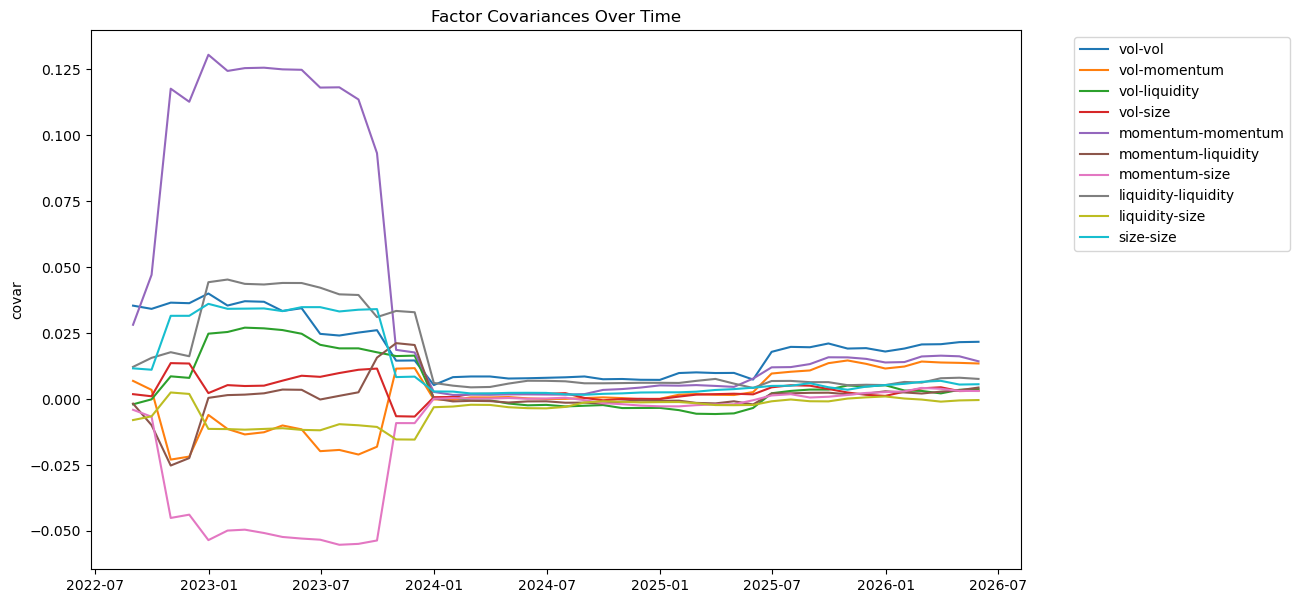

In [23]:
window = 12 
rolling_cov = factor_returns_z.rolling(window).cov() 

factors_only = factor_returns_z.drop(columns=['const','Communication Services', 'Consumer Discretionary', 
                                              'Financials', 'Health Care', 'Industrials']) 

cov_series = {} 
dates = factors_only.index[window-1:] 
factor_names = factors_only.columns 

for i in range(len(factor_names)): 
    for j in range(i, len(factor_names)): 
        f1 = factor_names[i] 
        f2 = factor_names[j] 
        
        name = f"{f1}-{f2}" 
        cov_series[name] = [ rolling_cov.loc[date].loc[f1, f2] for date in dates ] 
        
import matplotlib.pyplot as plt 
        
plt.figure(figsize=(12,7)) 
        
for name, series in cov_series.items(): 
    plt.plot(dates, series, label=name) 
            
plt.title('Factor Covariances Over Time') 
plt.ylabel('covar')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

In [24]:
def load_ff_daily(path, skiprows, nrows=None, col_names=None):
    df = pd.read_csv(
        path,
        skiprows=skiprows,
        nrows=nrows,
        index_col=0,
        na_values=['-99.99', '-999']
    )
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format='%Y%m%d', errors='coerce')
    df = df[df.index.notna()]
    df.index.name = 'Date'
    if col_names:
        df.columns = col_names
    else:
        df.columns = df.columns.str.strip()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df / 100 
    df = df.dropna(how='all')
    df_monthly = df.resample('ME').sum()
    return df_monthly

ap_factors = load_ff_daily('ap_factors.csv', skiprows=6)
print("AP Factors (monthly) shape:", ap_factors.shape)
print(ap_factors.tail(3))

AP Factors (monthly) shape: (428, 4)
            Mkt-RF     SMB     HML      RF
Date                                      
2025-12-31  0.0124  0.0248  0.0030  0.0023
2026-01-31  0.0614 -0.0037  0.0617  0.0022
2026-02-28  0.0430 -0.0272  0.0341  0.0020


In [25]:
industry_vw = load_ff_daily(
    'ind.csv',
    skiprows=10,
    nrows=26192,
    col_names=['Cnsmr', 'Manuf', 'HiTec', 'Hlth', 'Other']
)
print("Industry VW (monthly) shape:", industry_vw.shape)
print(industry_vw.tail(3))

Industry VW (monthly) shape: (1196, 5)
             Cnsmr   Manuf   HiTec    Hlth   Other
Date                                              
2025-12-31 -0.0022 -0.0024 -0.0037 -0.0146  0.0198
2026-01-31  0.0396  0.0930 -0.0059  0.0062 -0.0074
2026-02-28 -0.0079  0.0788 -0.0445  0.0462 -0.0075


In [26]:
stock_industry_map = {'PLY.AX': 'Cnsmr', 'LAU.AX': 'Manuf', 'ANG.AX': 'Manuf','TLX.AX': 'Hlth','COS.AX': 'HiTec',
                      'WTC.AX': 'HiTec','DUG.AX': 'HiTec', 'VVA.AX': 'Cnsmr','AUB.AX': 'Other'}

common_index = monthly_returns.index \
    .intersection(ap_factors.index) \
    .intersection(industry_vw.index)

stock_ret   = monthly_returns.loc[common_index]
ff_factors  = ap_factors.loc[common_index, ['Mkt-RF', 'SMB', 'HML']]
rf          = ap_factors.loc[common_index, 'RF']
ind_ret_all = industry_vw.loc[common_index]

stock_excess = stock_ret.sub(rf, axis=0)

print(f"Aligned dataset: {len(common_index)} monthly observations")
print(f"Date range: {common_index[0].date()} → {common_index[-1].date()}")


Aligned dataset: 57 monthly observations
Date range: 2021-06-30 → 2026-02-28


In [27]:
betas_n     = {}  
r_squared_n = {}
residuals_n = {}

for stock in tickers:
    ind_col = stock_industry_map[stock]

    y = stock_excess[stock].dropna()

    X = pd.concat([
        ff_factors[['Mkt-RF', 'SMB', 'HML']],
        ind_ret_all[ind_col].rename('Ind')
    ], axis=1).loc[y.index]

    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

    betas_n[stock]     = model.params
    r_squared_n[stock] = model.rsquared
    residuals_n[stock] = model.resid

betas_df_n = pd.DataFrame(betas_n).T
r_sq_n     = pd.Series(r_squared_n, name='R²')

print(betas_df_n.round(4))
print(r_sq_n.round(4))

         const  Mkt-RF     SMB     HML     Ind
PLY.AX -0.0165  1.5785  2.9337  1.1764  0.5971
LAU.AX  0.0190  0.1121 -0.4710 -0.5599 -0.0944
COS.AX  0.0025 -0.1032  0.5024 -1.2656 -0.1893
ANG.AX  0.0152 -0.5266  0.4241 -1.0433  0.5727
VVA.AX  0.0056  0.4313  1.7907 -0.5441 -0.3486
WTC.AX  0.0270 -0.0196 -0.3122 -2.3913  0.4410
AUB.AX  0.0161 -0.2085  0.2821 -1.0357  0.1684
TLX.AX  0.0346 -0.9055 -0.8022 -2.4954  0.6906
DUG.AX  0.0002  0.8139  0.5755  0.7114 -0.0718
PLY.AX    0.1919
LAU.AX    0.0363
COS.AX    0.0998
ANG.AX    0.0863
VVA.AX    0.1257
WTC.AX    0.3989
AUB.AX    0.1801
TLX.AX    0.2383
DUG.AX    0.0356
Name: R², dtype: float64


In [28]:
used_industries = list(set(stock_industry_map.values()))

factor_ret = pd.concat([
    ff_factors,
    ind_ret_all[used_industries]
], axis=1)

F = factor_ret.cov()
print("Factor covariance matrix (F):")
print(F.round(8))

Factor covariance matrix (F):
          Mkt-RF       SMB       HML     Manuf      Hlth     Cnsmr     Other  \
Mkt-RF  0.002036 -0.000152 -0.000654  0.001545  0.000949  0.001360  0.001459   
SMB    -0.000152  0.000431 -0.000059 -0.000057 -0.000114  0.000118 -0.000012   
HML    -0.000654 -0.000059  0.000960 -0.000605 -0.000607 -0.001155 -0.000973   
Manuf   0.001545 -0.000057 -0.000605  0.002261  0.001178  0.001554  0.001885   
Hlth    0.000949 -0.000114 -0.000607  0.001178  0.001878  0.001051  0.001299   
Cnsmr   0.001360  0.000118 -0.001155  0.001554  0.001051  0.002379  0.001905   
Other   0.001459 -0.000012 -0.000973  0.001885  0.001299  0.001905  0.002451   
HiTec   0.001360  0.000187 -0.001200  0.001449  0.001199  0.002341  0.001884   

           HiTec  
Mkt-RF  0.001360  
SMB     0.000187  
HML    -0.001200  
Manuf   0.001449  
Hlth    0.001199  
Cnsmr   0.002341  
Other   0.001884  
HiTec   0.003298  


In [29]:
resid_df  = pd.DataFrame(residuals_n)
idio_var_  = resid_df.var(ddof=1)
D         = np.diag(idio_var_.values)

print(idio_var.round(8))

PLY.AX    0.037407
LAU.AX    0.010525
COS.AX    0.008725
ANG.AX    0.015157
VVA.AX    0.008689
WTC.AX    0.013896
AUB.AX    0.005283
TLX.AX    0.025100
DUG.AX    0.021965
dtype: float64


In [32]:
factor_cols = list(F.columns) 

B_rows = []
for stock in tickers:
    row = []
    for fc in factor_cols:
        ind_col = stock_industry_map[stock]
        
        if fc == ind_col:
            row.append(betas_df_n.loc[stock, 'Ind'])
        elif fc in betas_df_n.columns:
            row.append(betas_df_n.loc[stock, fc])
        else:
            row.append(0.0) 
    B_rows.append(row)

B = np.array(B_rows)

Sigma = B @ F.values @ B.T + D
Sigma_df = pd.DataFrame(Sigma, index=tickers, columns=tickers)

print("Full covariance matrix Σ (annualised, ×252):")
print((Sigma_df * np.sqrt(252)).round(6))

Full covariance matrix Σ (annualised, ×252):
          PLY.AX    LAU.AX    COS.AX    ANG.AX    VVA.AX    WTC.AX    AUB.AX  \
PLY.AX  0.667961  0.000400  0.010891  0.018687  0.040900  0.041850  0.013918   
LAU.AX  0.000400  0.178338  0.006463  0.006098 -0.000368  0.024898  0.007544   
COS.AX  0.010891  0.006463  0.182647  0.017934  0.012666  0.040551  0.017805   
ANG.AX  0.018687  0.006098  0.017934  0.293004  0.012205  0.047576  0.020318   
VVA.AX  0.040900 -0.000368  0.012666  0.012205  0.192846  0.020944  0.011108   
WTC.AX  0.041850  0.024898  0.040551  0.047576  0.020944  0.337361  0.047520   
AUB.AX  0.013918  0.007544  0.017805  0.020318  0.011108  0.047520  0.108185   
TLX.AX -0.011368  0.019934  0.034304  0.039158  0.006029  0.100166  0.038631   
DUG.AX  0.034002 -0.001565 -0.005545 -0.005037  0.006088 -0.007493 -0.005412   

          TLX.AX    DUG.AX  
PLY.AX -0.011368  0.034002  
LAU.AX  0.019934 -0.001565  
COS.AX  0.034304 -0.005545  
ANG.AX  0.039158 -0.005037  
VVA.AX  0

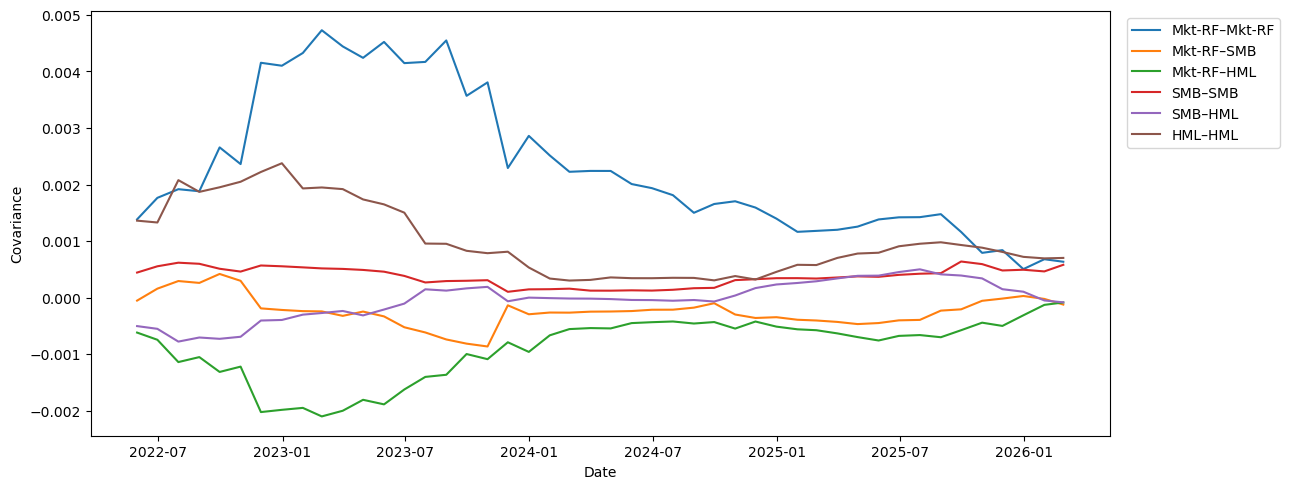

In [31]:
window = 12  

rolling_cov = factor_ret[['Mkt-RF', 'SMB', 'HML']].rolling(window).cov()

cov_series = {}
factor_names = ['Mkt-RF', 'SMB', 'HML']
dates = factor_ret.index[window - 1:]

for i in range(len(factor_names)):
    for j in range(i, len(factor_names)):
        f1, f2 = factor_names[i], factor_names[j]
        name = f"{f1}–{f2}"
        cov_series[name] = [rolling_cov.loc[d].loc[f1, f2] for d in dates]

plt.figure(figsize=(13, 5))
for name, series in cov_series.items():
    plt.plot(dates, series, label=name)

plt.ylabel('Covariance')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()